In [118]:
import pandas as pd

df = pd.read_csv("../data/online_retail_II.csv")

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [119]:
df.shape

(1067371, 8)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [121]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [122]:
df.duplicated().sum()

34335

In [123]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


Week 1 – Day 3: Data Quality Assessment
Goal

Before deleting or modifying any data, we need to measure the quality of the dataset.

A good data analyst never starts cleaning without first understanding what needs cleaning.

Today's objectives are to:

Count missing Customer IDs.
Count duplicate rows.
Count cancelled transactions.
Count invalid quantities.
Count invalid prices.

These findings will justify our cleaning decisions in the notebook.

In [124]:
# Count missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [125]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [126]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 34335


In [127]:
cancelled_orders = df[df["Invoice"].astype(str).str.startswith("C")]

print("Cancelled Transactions:", cancelled_orders.shape[0])

Cancelled Transactions: 19494


In [128]:
invalid_quantity = df[df["Quantity"] <= 0]

print("Quantity <= 0 :", invalid_quantity.shape[0])

Quantity <= 0 : 22950


In [129]:
invalid_price = df[df["Price"] <= 0]

print("Price <= 0 :", invalid_price.shape[0])

Price <= 0 : 6207


In [130]:
# Display all column names
print("Dataset Columns:")
for column in df.columns:
    print(column)

Dataset Columns:
Invoice
StockCode
Description
Quantity
InvoiceDate
Price
Customer ID
Country


In [131]:
# Count rows with missing Customer ID
missing_customer_ids = df["Customer ID"].isnull().sum()

print("Missing Customer IDs:", missing_customer_ids)

Missing Customer IDs: 243007


In [132]:
# Calculate the percentage of rows with missing Customer ID
missing_customer_percentage = (
    missing_customer_ids / len(df)
) * 100

print(
    "Missing Customer ID Percentage:",
    round(missing_customer_percentage, 2),
    "%"
)

Missing Customer ID Percentage: 22.77 %


In [133]:
# Count completely duplicated rows
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 34335


In [134]:
# Display sample duplicated records
df[df.duplicated(keep=False)].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


### Data Quality Findings

- The dataset contains missing Customer IDs, which cannot be used for customer-level cohort and CLTV analysis.
- Duplicate transaction rows may inflate revenue and purchase-frequency calculations.
- These issues will be handled in the next cleaning stage.

In [135]:
# Find invoices that start with "C"
cancelled_orders = df[df["Invoice"].astype(str).str.startswith("C")]

print("Cancelled Orders:", cancelled_orders.shape[0])

Cancelled Orders: 19494


In [136]:
invalid_quantity = df[df["Quantity"] <= 0]

print("Transactions with Quantity <= 0:", invalid_quantity.shape[0])

Transactions with Quantity <= 0: 22950


In [137]:
invalid_quantity.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [138]:
invalid_price = df[df["Price"] <= 0]

print("Transactions with Price <= 0:", invalid_price.shape[0])

Transactions with Price <= 0: 6207


In [139]:
invalid_price.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


## Data Quality Assessment

The dataset contains several transaction types that require cleaning before cohort analysis.

### Findings

- Cancelled invoices are identified by invoice numbers beginning with "C".
- Transactions with Quantity ≤ 0 represent returns, cancellations, or invalid entries.
- Transactions with Price ≤ 0 require further investigation before revenue calculations.

These records will be cleaned in the next stage before creating Cohort Month and CLTV metrics.

In [140]:
# Create a copy of the original dataset
clean_df = df.copy()

In [141]:
clean_df = clean_df.dropna(subset=["Customer ID"])

In [142]:
clean_df = clean_df.drop_duplicates()

In [143]:
clean_df = clean_df[
    ~clean_df["Invoice"].astype(str).str.startswith("C")
]

In [144]:
clean_df = clean_df[
    clean_df["Quantity"] > 0
]

In [145]:
clean_df = clean_df[
    clean_df["Price"] > 0
]

In [146]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", clean_df.shape)

Original Dataset Shape : (1067371, 8)
Cleaned Dataset Shape  : (779425, 8)


In [147]:
print("Missing Customer IDs :", clean_df["Customer ID"].isnull().sum())
print("Duplicate Rows       :", clean_df.duplicated().sum())
print("Invalid Quantity     :", (clean_df["Quantity"] <= 0).sum())
print("Invalid Price        :", (clean_df["Price"] <= 0).sum())

Missing Customer IDs : 0
Duplicate Rows       : 0
Invalid Quantity     : 0
Invalid Price        : 0


## Data Cleaning Summary

The original dataset contained several data quality issues that could affect customer retention and CLTV analysis.

The following cleaning steps were performed:

- Removed records with missing Customer IDs.
- Removed duplicate transaction records.
- Removed cancelled invoices.
- Removed transactions with non-positive quantities.
- Removed transactions with non-positive prices.

The cleaned dataset will be used for all subsequent cohort and CLTV calculations.

In [148]:
# Convert InvoiceDate from text/object format to datetime format
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

In [149]:
# Count invalid or missing dates after conversion
invalid_dates = clean_df["InvoiceDate"].isna().sum()

print("Invalid Invoice Dates:", invalid_dates)

Invalid Invoice Dates: 0


In [150]:
clean_df[clean_df["InvoiceDate"].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [151]:
# Calculate revenue generated by each transaction row
clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["Price"]
)

In [152]:
clean_df[
    ["Invoice", "Quantity", "Price", "Revenue"]
].head()

,Invoice,Quantity,Price,Revenue
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0


In [153]:
# Extract the calendar month of each transaction
clean_df["InvoiceMonth"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [154]:
clean_df[
    [
        "InvoiceDate",
        "InvoiceMonth",
        "Quantity",
        "Price",
        "Revenue"
    ]
].head()

,InvoiceDate,InvoiceMonth,Quantity,Price,Revenue
0,2009-12-01 07:45:00,2009-12-01,12,6.95,83.4
1,2009-12-01 07:45:00,2009-12-01,12,6.75,81.0
2,2009-12-01 07:45:00,2009-12-01,12,6.75,81.0
3,2009-12-01 07:45:00,2009-12-01,48,2.10,100.8
4,2009-12-01 07:45:00,2009-12-01,24,1.25,30.0


In [155]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 779425 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       779425 non-null  object        
 1   StockCode     779425 non-null  object        
 2   Description   779425 non-null  object        
 3   Quantity      779425 non-null  int64         
 4   InvoiceDate   779425 non-null  datetime64[ns]
 5   Price         779425 non-null  float64       
 6   Customer ID   779425 non-null  float64       
 7   Country       779425 non-null  object        
 8   Revenue       779425 non-null  float64       
 9   InvoiceMonth  779425 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(3), int64(1), object(4)
memory usage: 65.4+ MB


In [156]:
print("Minimum Revenue:", clean_df["Revenue"].min())
print("Maximum Revenue:", clean_df["Revenue"].max())
print("Total Revenue:", clean_df["Revenue"].sum())

print(
    "Transaction Period:",
    clean_df["InvoiceDate"].min(),
    "to",
    clean_df["InvoiceDate"].max()
)

Minimum Revenue: 0.001
Maximum Revenue: 168469.6
Total Revenue: 17374804.268000003
Transaction Period: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## Revenue and Date Preparation

The cleaned transaction dates were converted to a proper datetime format so that monthly customer activity can be analyzed accurately.

A Revenue column was calculated using:

Revenue = Quantity × Price

The InvoiceMonth field was then created by reducing each transaction date to its corresponding calendar month. These fields will support cohort assignment, retention analysis, and CLTV calculations.

In [157]:
# Find the first purchase month for each customer
cohort_data = clean_df.groupby("Customer ID")["InvoiceMonth"].min()

cohort_data.head()

Customer ID
12346.0   2009-12-01
12347.0   2010-10-01
12348.0   2010-09-01
12349.0   2010-04-01
12350.0   2011-02-01
Name: InvoiceMonth, dtype: datetime64[ns]

In [158]:
cohort_data = cohort_data.rename("CohortMonth")

In [159]:
clean_df = clean_df.merge(
    cohort_data,
    on="Customer ID"
)

clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceMonth,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12-01,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12-01,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12-01,2009-12-01


In [160]:
clean_df[
    [
        "Customer ID",
        "InvoiceMonth",
        "CohortMonth"
    ]
].head(15)

,Customer ID,InvoiceMonth,CohortMonth
0,13085.0,2009-12-01,2009-12-01
1,13085.0,2009-12-01,2009-12-01
2,13085.0,2009-12-01,2009-12-01
3,13085.0,2009-12-01,2009-12-01
4,13085.0,2009-12-01,2009-12-01
5,13085.0,2009-12-01,2009-12-01
6,13085.0,2009-12-01,2009-12-01
7,13085.0,2009-12-01,2009-12-01
8,13085.0,2009-12-01,2009-12-01
9,13085.0,2009-12-01,2009-12-01


In [161]:
print(
    "Number of Cohorts:",
    clean_df["CohortMonth"].nunique()
)

Number of Cohorts: 25


## Cohort Assignment

Each customer was assigned to a cohort based on the month of their first recorded purchase.

The CohortMonth remains fixed for every customer regardless of subsequent purchases.

This allows customers acquired during the same month to be analysed together throughout the remainder of the project.

In [162]:
# Extract year and month from InvoiceMonth
invoice_year = clean_df["InvoiceMonth"].dt.year
invoice_month = clean_df["InvoiceMonth"].dt.month

# Extract year and month from CohortMonth
cohort_year = clean_df["CohortMonth"].dt.year
cohort_month = clean_df["CohortMonth"].dt.month

In [163]:
clean_df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
)

In [164]:
clean_df[
    [
        "Customer ID",
        "CohortMonth",
        "InvoiceMonth",
        "CohortIndex"
    ]
].head(20)

,Customer ID,CohortMonth,InvoiceMonth,CohortIndex
0,13085.0,2009-12-01,2009-12-01,0
1,13085.0,2009-12-01,2009-12-01,0
2,13085.0,2009-12-01,2009-12-01,0
3,13085.0,2009-12-01,2009-12-01,0
4,13085.0,2009-12-01,2009-12-01,0
5,13085.0,2009-12-01,2009-12-01,0
6,13085.0,2009-12-01,2009-12-01,0
7,13085.0,2009-12-01,2009-12-01,0
8,13085.0,2009-12-01,2009-12-01,0
9,13085.0,2009-12-01,2009-12-01,0


In [165]:
print("Minimum Cohort Index:", clean_df["CohortIndex"].min())
print("Maximum Cohort Index:", clean_df["CohortIndex"].max())

Minimum Cohort Index: 0
Maximum Cohort Index: 24


In [166]:
negative_index = clean_df[clean_df["CohortIndex"] < 0]

print("Negative Cohort Index:", len(negative_index))

Negative Cohort Index: 0


## Cohort Index Calculation

The Cohort Index represents the number of months since each customer's first purchase.

- Month 0 represents the acquisition month.
- Month 1 represents one month after acquisition.
- Month 2 represents two months after acquisition.

The Cohort Index is used to measure customer retention over time and forms the basis of the cohort retention matrix.

In [167]:
# Count unique customers for each Cohort Month and Cohort Index
cohort_counts = (
    clean_df
    .groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
)

In [168]:
cohort_counts.head(15)

CohortMonth  CohortIndex
2009-12-01   0              955
             1              337
             2              319
             3              406
             4              363
             5              343
             6              360
             7              327
             8              321
             9              346
             10             403
             11             473
             12             359
             13             270
             14             233
Name: Customer ID, dtype: int64

In [169]:
cohort_matrix = cohort_counts.unstack(fill_value=0)

In [170]:
cohort_matrix.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,955,337,319,406,363,343,360,327,321,346,...,289,251,289,270,248,244,301,291,389,188
2010-01-01,383,79,119,117,101,115,99,88,107,122,...,58,90,76,71,75,93,74,94,22,0
2010-02-01,374,89,84,109,92,75,72,107,95,103,...,75,60,61,54,86,86,61,22,0,0
2010-03-01,443,84,102,107,103,90,109,134,122,48,...,75,77,69,78,89,94,35,0,0,0
2010-04-01,294,57,57,48,54,66,81,77,31,32,...,46,41,44,53,66,17,0,0,0,0


In [171]:
# Calculate retention percentage for each cohort
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
)

In [172]:
print("Matrix Shape:", cohort_matrix.shape)

Matrix Shape: (25, 25)


In [173]:
print(cohort_matrix.iloc[:, 0].head())

CohortMonth
2009-12-01    955
2010-01-01    383
2010-02-01    374
2010-03-01    443
2010-04-01    294
Name: 0, dtype: int64


## Cohort Retention Matrix

The transaction data was grouped by:

- Cohort Month
- Cohort Index

The number of unique customers was calculated for every cohort and every month after acquisition.

The resulting matrix forms the foundation for calculating customer retention percentages.

In [174]:
# Convert retention ratios to percentages
retention_percentage = retention_matrix * 100

In [175]:
retention_percentage = retention_percentage.round(2)

In [176]:
retention_percentage.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,0.00
2010-02-01,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,0.00,0.00
2010-03-01,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,0.00,0.00,0.00
2010-04-01,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,0.00,0.00,0.00,0.00


In [177]:
print(retention_percentage.iloc[:, 0].head())

CohortMonth
2009-12-01    100.0
2010-01-01    100.0
2010-02-01    100.0
2010-03-01    100.0
2010-04-01    100.0
Name: 0, dtype: float64


In [178]:
print(retention_percentage.iloc[:5, :6])

CohortIndex      0      1      2      3      4      5
CohortMonth                                          
2009-12-01   100.0  35.29  33.40  42.51  38.01  35.92
2010-01-01   100.0  20.63  31.07  30.55  26.37  30.03
2010-02-01   100.0  23.80  22.46  29.14  24.60  20.05
2010-03-01   100.0  18.96  23.02  24.15  23.25  20.32
2010-04-01   100.0  19.39  19.39  16.33  18.37  22.45


## Cohort Retention Percentage Matrix

The retention count matrix was converted into retention percentages by dividing each month's customer count by the number of customers in Month 0 for the corresponding cohort.

This standardizes the cohorts, allowing fair comparison of customer retention regardless of the original cohort size.

The resulting matrix will be used to generate the retention heatmap.

In [179]:
import matplotlib.pyplot as plt

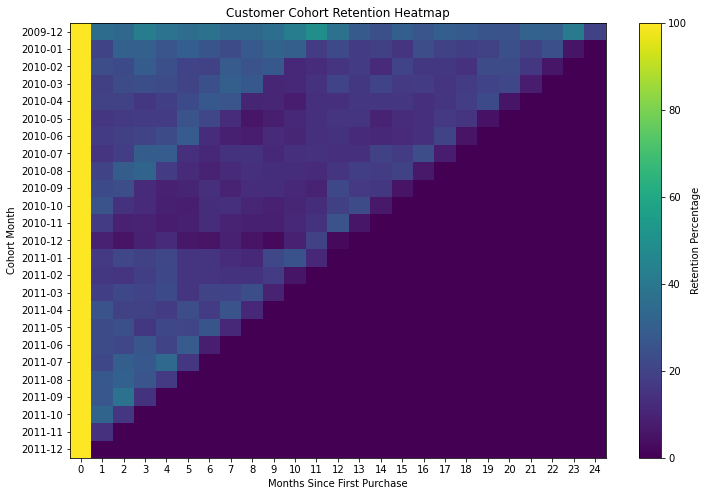

In [180]:
plt.figure(figsize=(12, 8))

plt.imshow(retention_percentage, aspect="auto")

plt.colorbar(label="Retention Percentage")

plt.title("Customer Cohort Retention Heatmap")

plt.xlabel("Months Since First Purchase")

plt.ylabel("Cohort Month")

plt.xticks(range(len(retention_percentage.columns)), retention_percentage.columns)
plt.yticks(range(len(retention_percentage.index)),
           retention_percentage.index.strftime("%Y-%m"))

plt.show()

## Heatmap Interpretation

### Observations

- Month 0 shows 100% retention for every cohort.
- Retention generally decreases over time.
- The largest decline occurs during the first few months after customer acquisition.
- Some cohorts retain customers better than others.

### Business Insight

The company should investigate why customers stop purchasing shortly after acquisition.

Possible actions include:

- Personalized follow-up emails
- Loyalty rewards
- Discount campaigns
- Product recommendations

In [181]:
import os

print(os.getcwd())

c:\Users\azmia\SaaS-ECommerce-Cohort-Retention-CLTV-Analysis\notebooks


In [182]:
import os

print(os.listdir())

['.gitkeep', '.ipynb_checkpoints', 'week1-datacleaning.ipynb']


In [183]:
import os

print(os.path.exists("../output"))

True


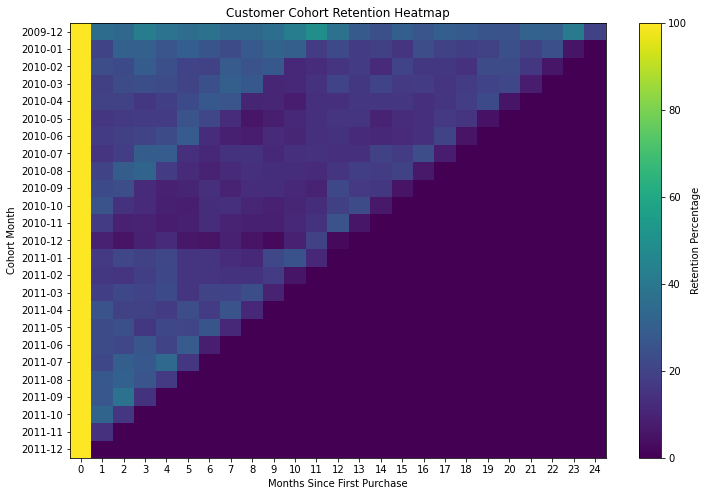

In [184]:

plt.figure(figsize=(12, 8))

plt.imshow(retention_percentage, aspect="auto")

plt.colorbar(label="Retention Percentage")

plt.title("Customer Cohort Retention Heatmap")

plt.xlabel("Months Since First Purchase")

plt.ylabel("Cohort Month")

plt.xticks(range(len(retention_percentage.columns)), retention_percentage.columns)
plt.yticks(range(len(retention_percentage.index)),
           retention_percentage.index.strftime("%Y-%m"))

plt.savefig("../output/cohort_retention_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [185]:
customer_summary = (
    clean_df
    .groupby("Customer ID")
    .agg({
        "Revenue": "sum",
        "Invoice": "nunique",
        "Quantity": "sum"
    })
)

In [186]:
customer_summary = customer_summary.rename(columns={
    "Revenue": "TotalRevenue",
    "Invoice": "NumberOfOrders",
    "Quantity": "TotalItems"
})

In [187]:
customer_summary.head(10)

,TotalRevenue,NumberOfOrders,TotalItems
Customer ID,,,
12346.0,77556.46,12,74285
12347.0,4921.53,8,2967
12348.0,2019.40,5,2714
12349.0,4428.69,4,1624
12350.0,334.40,1,197
12351.0,300.93,1,261
12352.0,2849.84,10,724
12353.0,406.76,2,212
12354.0,1079.40,1,530


In [188]:
customer_summary.describe()

,TotalRevenue,NumberOfOrders,TotalItems
count,5878.000000,5878.000000,5878.000000
mean,2955.904095,6.289384,1788.695475
std,14440.852688,13.009406,8876.297196
min,2.950000,1.000000,1.000000
25%,342.280000,1.000000,187.000000
50%,867.740000,3.000000,480.000000
75%,2248.305000,7.000000,1350.000000
max,580987.040000,398.000000,367193.000000


In [189]:
top_customers = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
)

top_customers.head(10)

,TotalRevenue,NumberOfOrders,TotalItems
Customer ID,,,
18102.0,580987.04,145,181645
14646.0,528602.52,151,367193
14156.0,313437.62,156,164325
14911.0,291420.81,398,147972
17450.0,244784.25,51,83914
13694.0,195640.69,143,188201
17511.0,172132.87,60,117174
16446.0,168472.50,2,80997
16684.0,147142.77,55,104810


In [190]:
customer_summary.to_csv("../output/customer_summary.csv")

## Customer Revenue Summary

Customer-level metrics were calculated by aggregating all transactions for each customer.

The summary includes:

- Total revenue generated
- Number of unique orders
- Total quantity of purchased items

These metrics form the foundation for Average Order Value, Purchase Frequency, and Customer Lifetime Value calculations.

In [191]:
# Calculate Average Order Value for each customer
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["NumberOfOrders"]
)

In [192]:
customer_summary["PurchaseFrequency"] = (
    customer_summary["NumberOfOrders"]
)

In [193]:
customer_summary[
    [
        "TotalRevenue",
        "NumberOfOrders",
        "AverageOrderValue",
        "PurchaseFrequency"
    ]
].head(10)

,TotalRevenue,NumberOfOrders,AverageOrderValue,PurchaseFrequency
Customer ID,,,,
12346.0,77556.46,12,6463.038333,12
12347.0,4921.53,8,615.191250,8
12348.0,2019.40,5,403.880000,5
12349.0,4428.69,4,1107.172500,4
12350.0,334.40,1,334.400000,1
12351.0,300.93,1,300.930000,1
12352.0,2849.84,10,284.984000,10
12353.0,406.76,2,203.380000,2
12354.0,1079.40,1,1079.400000,1


In [194]:
customer_summary[
    [
        "AverageOrderValue",
        "PurchaseFrequency"
    ]
].describe()

,AverageOrderValue,PurchaseFrequency
count,5878.000000,5878.000000
mean,385.180841,6.289384
std,1214.286459,13.009406
min,2.950000,1.000000
25%,176.682500,1.000000
50%,279.242679,3.000000
75%,414.902458,7.000000
max,84236.250000,398.000000


In [195]:
customer_summary.to_csv(
    "../output/customer_summary.csv",
    index=True
)

## Average Order Value and Purchase Frequency

Two customer-level metrics were calculated:

- **Average Order Value (AOV):** The average amount spent per order.
- **Purchase Frequency:** The number of orders placed by each customer.

These metrics provide insight into customer purchasing behavior and are essential inputs for Customer Lifetime Value (CLTV) analysis.

In [196]:
# Calculate first and last purchase dates for each customer
customer_lifespan = (
    clean_df
    .groupby("Customer ID")["InvoiceDate"]
    .agg(["min", "max"])
)

# Calculate lifespan in days
customer_lifespan["CustomerLifespanDays"] = (
    customer_lifespan["max"] -
    customer_lifespan["min"]
).dt.days

customer_lifespan.head()

,min,max,CustomerLifespanDays
Customer ID,,,
12346.0,2009-12-14 08:34:00,2011-01-18 10:01:00,400
12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,402
12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,362
12349.0,2010-04-29 13:20:00,2011-11-21 09:51:00,570
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [197]:
customer_summary = customer_summary.merge(
    customer_lifespan["CustomerLifespanDays"],
    on="Customer ID"
)

In [198]:
customer_summary["CustomerLifespanMonths"] = (
    customer_summary["CustomerLifespanDays"] / 30
).round(2)

In [199]:
customer_summary["HistoricalCLTV"] = (
    customer_summary["AverageOrderValue"] *
    customer_summary["PurchaseFrequency"]
)

In [200]:
top_cltv = customer_summary.sort_values(
    by="HistoricalCLTV",
    ascending=False
)

top_cltv.head(10)

,TotalRevenue,NumberOfOrders,TotalItems,AverageOrderValue,PurchaseFrequency,CustomerLifespanDays,CustomerLifespanMonths,HistoricalCLTV
Customer ID,,,,,,,,
18102.0,580987.04,145,181645,4006.807172,145,738,24.60,580987.04
14646.0,528602.52,151,367193,3500.678940,151,735,24.50,528602.52
14156.0,313437.62,156,164325,2009.215513,156,728,24.27,313437.62
14911.0,291420.81,398,147972,732.213090,398,737,24.57,291420.81
17450.0,244784.25,51,83914,4799.691176,51,429,14.30,244784.25
13694.0,195640.69,143,188201,1368.116713,143,731,24.37,195640.69
17511.0,172132.87,60,117174,2868.881167,60,734,24.47,172132.87
16446.0,168472.50,2,80997,84236.250000,2,204,6.80,168472.50
16684.0,147142.77,55,104810,2675.323091,55,728,24.27,147142.77


In [201]:
customer_summary["HistoricalCLTV"].describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: HistoricalCLTV, dtype: float64

## Historical Customer Lifetime Value

Historical CLTV was calculated using customer purchasing behavior observed within the available dataset.

This metric estimates the total revenue generated by each customer during the recorded period and helps identify high-value customers for targeted retention strategies.

In [202]:
customer_summary["ValueSegment"] = pd.qcut(
    customer_summary["HistoricalCLTV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [203]:
customer_summary["ValueSegment"].value_counts()

Low Value       1960
Medium Value    1959
High Value      1959
Name: ValueSegment, dtype: int64

In [204]:
segment_summary = (
    customer_summary
    .groupby("ValueSegment", observed=True)
    .agg(
        Customers=("HistoricalCLTV", "count"),
        AverageCLTV=("HistoricalCLTV", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        AverageOrders=("NumberOfOrders", "mean")
    )
    .round(2)
)

segment_summary

,Customers,AverageCLTV,AverageOrderValue,AverageOrders
ValueSegment,,,,
Low Value,1960,244.07,189.65,1.45
Medium Value,1959,914.61,338.20,3.44
High Value,1959,7710.41,627.79,13.98


In [205]:
country_summary = (
    clean_df
    .groupby("Country")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        UniqueCustomers=("Customer ID", "nunique"),
        NumberOfOrders=("Invoice", "nunique")
    )
    .reset_index()
)

In [206]:
country_summary["RevenuePerCustomer"] = (
    country_summary["TotalRevenue"] /
    country_summary["UniqueCustomers"]
)

In [207]:
country_summary = country_summary.sort_values(
    "TotalRevenue",
    ascending=False
)

country_summary.head(10)

,Country,TotalRevenue,UniqueCustomers,NumberOfOrders,RevenuePerCustomer
38,United Kingdom,1.438923e+07,5350,33541,2689.576620
10,EIRE,6.165705e+05,5,567,123314.108000
24,Netherlands,5.540381e+05,22,228,25183.549545
14,Germany,4.250197e+05,107,789,3972.146832
13,France,3.487690e+05,95,614,3671.252211
0,Australia,1.692835e+05,15,95,11285.564000
32,Spain,1.083325e+05,41,154,2642.255854
34,Switzerland,1.000619e+05,22,90,4548.270000
33,Sweden,9.151582e+04,19,104,4816.622105
9,Denmark,6.858069e+04,12,43,5715.057500


In [208]:
country_summary.sort_values(
    "RevenuePerCustomer",
    ascending=False
).head(10)

,Country,TotalRevenue,UniqueCustomers,NumberOfOrders,RevenuePerCustomer
10,EIRE,616570.54,5,567,123314.108000
31,Singapore,25317.06,1,11,25317.060000
24,Netherlands,554038.09,22,228,25183.549545
0,Australia,169283.46,15,95,11285.564000
9,Denmark,68580.69,12,43,5715.057500
16,Iceland,4921.53,1,8,4921.530000
22,Lithuania,4892.68,1,6,4892.680000
33,Sweden,91515.82,19,104,4816.622105
34,Switzerland,100061.94,22,90,4548.270000
26,Norway,56322.50,13,45,4332.500000


In [209]:
country_summary.to_csv(
    "../output/country_summary.csv",
    index=False
)

In [210]:
customer_summary["ActiveMonths"] = (
    customer_summary["CustomerLifespanDays"] / 30.44
).clip(lower=1)

In [211]:
customer_summary["MonthlyCustomerValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["ActiveMonths"]
)

In [212]:
customer_summary["Projected12MonthCLTV"] = (
    customer_summary["MonthlyCustomerValue"] * 12
)

In [213]:
print(customer_summary.columns.tolist())

['TotalRevenue', 'NumberOfOrders', 'TotalItems', 'AverageOrderValue', 'PurchaseFrequency', 'CustomerLifespanDays', 'CustomerLifespanMonths', 'HistoricalCLTV', 'ValueSegment', 'ActiveMonths', 'MonthlyCustomerValue', 'Projected12MonthCLTV']


In [214]:
customer_summary["ActiveMonths"] = (
    customer_summary["CustomerLifespanDays"] / 30.44
).clip(lower=1)

In [215]:
customer_summary["MonthlyCustomerValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["ActiveMonths"]
)

In [216]:
customer_summary["Projected12MonthCLTV"] = (
    customer_summary["MonthlyCustomerValue"] * 12
)

In [217]:
print(customer_summary.columns.tolist())

['TotalRevenue', 'NumberOfOrders', 'TotalItems', 'AverageOrderValue', 'PurchaseFrequency', 'CustomerLifespanDays', 'CustomerLifespanMonths', 'HistoricalCLTV', 'ValueSegment', 'ActiveMonths', 'MonthlyCustomerValue', 'Projected12MonthCLTV']


In [218]:
customer_summary[
    [
        "TotalRevenue",
        "ActiveMonths",
        "MonthlyCustomerValue",
        "Projected12MonthCLTV"
    ]
].head(10)

,TotalRevenue,ActiveMonths,MonthlyCustomerValue,Projected12MonthCLTV
Customer ID,,,,
12346.0,77556.46,13.140604,5902.046606,70824.559272
12347.0,4921.53,13.206307,372.665107,4471.981290
12348.0,2019.40,11.892247,169.808110,2037.697326
12349.0,4428.69,18.725361,236.507585,2838.091023
12350.0,334.40,1.000000,334.400000,4012.800000
12351.0,300.93,1.000000,300.930000,3611.160000
12352.0,2849.84,11.695138,243.677330,2924.127964
12353.0,406.76,6.701708,60.694973,728.339671
12354.0,1079.40,1.000000,1079.400000,12952.800000


In [219]:
customer_summary["Projected12MonthCLTV"].describe()

count      5878.000000
mean       4317.421908
std       13133.052661
min          19.974233
25%        1170.000000
50%        2181.522921
75%        4191.180000
max      478998.000000
Name: Projected12MonthCLTV, dtype: float64

In [220]:
customer_summary.sort_values(
    "Projected12MonthCLTV",
    ascending=False
).head(10)

,TotalRevenue,NumberOfOrders,TotalItems,AverageOrderValue,PurchaseFrequency,CustomerLifespanDays,CustomerLifespanMonths,HistoricalCLTV,ValueSegment,ActiveMonths,MonthlyCustomerValue,Projected12MonthCLTV
Customer ID,,,,,,,,,,,,
15098.0,39916.50,3,121,13305.500000,3,0,0.00,39916.50,High Value,1.000000,39916.500000,478998.000000
16446.0,168472.50,2,80997,84236.250000,2,204,6.80,168472.50,High Value,6.701708,25138.739706,301664.876471
18102.0,580987.04,145,181645,4006.807172,145,738,24.60,580987.04,High Value,24.244415,23963.747287,287564.967441
14646.0,528602.52,151,367193,3500.678940,151,735,24.50,528602.52,High Value,24.145861,21892.055386,262704.664633
14096.0,65164.79,17,16352,3833.222941,17,97,3.23,65164.79,High Value,3.186597,20449.651625,245395.819497
17450.0,244784.25,51,83914,4799.691176,51,429,14.30,244784.25,High Value,14.093298,17368.840490,208426.085874
15749.0,44534.30,3,18028,14844.766667,3,97,3.23,44534.30,High Value,3.186597,13975.506103,167706.073237
15760.0,13916.34,2,2,6958.170000,2,0,0.00,13916.34,High Value,1.000000,13916.340000,166996.080000
14156.0,313437.62,156,164325,2009.215513,156,728,24.27,313437.62,High Value,23.915900,13105.825759,157269.909112


In [221]:
customer_summary["Projected12MonthCLTV"]

Customer ID
12346.0    70824.559272
12347.0     4471.981290
12348.0     2037.697326
12349.0     2838.091023
12350.0     4012.800000
               ...     
18283.0     1488.432220
18284.0     5540.160000
18285.0     5124.000000
18286.0     1917.246763
18287.0     2893.868536
Name: Projected12MonthCLTV, Length: 5878, dtype: float64

In [222]:
customer_summary[
    [
        "TotalRevenue",
        "NumberOfOrders",
        "AverageOrderValue",
        "ActiveMonths",
        "MonthlyCustomerValue",
        "Projected12MonthCLTV"
    ]
].head(10)

,TotalRevenue,NumberOfOrders,AverageOrderValue,ActiveMonths,MonthlyCustomerValue,Projected12MonthCLTV
Customer ID,,,,,,
12346.0,77556.46,12,6463.038333,13.140604,5902.046606,70824.559272
12347.0,4921.53,8,615.191250,13.206307,372.665107,4471.981290
12348.0,2019.40,5,403.880000,11.892247,169.808110,2037.697326
12349.0,4428.69,4,1107.172500,18.725361,236.507585,2838.091023
12350.0,334.40,1,334.400000,1.000000,334.400000,4012.800000
12351.0,300.93,1,300.930000,1.000000,300.930000,3611.160000
12352.0,2849.84,10,284.984000,11.695138,243.677330,2924.127964
12353.0,406.76,2,203.380000,6.701708,60.694973,728.339671
12354.0,1079.40,1,1079.400000,1.000000,1079.400000,12952.800000


In [223]:
customer_summary["Projected12MonthCLTV"].describe()

count      5878.000000
mean       4317.421908
std       13133.052661
min          19.974233
25%        1170.000000
50%        2181.522921
75%        4191.180000
max      478998.000000
Name: Projected12MonthCLTV, dtype: float64

In [224]:
top_projected_customers = customer_summary.sort_values(
    by="Projected12MonthCLTV",
    ascending=False
)

top_projected_customers[
    [
        "TotalRevenue",
        "NumberOfOrders",
        "AverageOrderValue",
        "Projected12MonthCLTV"
    ]
].head(10)

,TotalRevenue,NumberOfOrders,AverageOrderValue,Projected12MonthCLTV
Customer ID,,,,
15098.0,39916.50,3,13305.500000,478998.000000
16446.0,168472.50,2,84236.250000,301664.876471
18102.0,580987.04,145,4006.807172,287564.967441
14646.0,528602.52,151,3500.678940,262704.664633
14096.0,65164.79,17,3833.222941,245395.819497
17450.0,244784.25,51,4799.691176,208426.085874
15749.0,44534.30,3,14844.766667,167706.073237
15760.0,13916.34,2,6958.170000,166996.080000
14156.0,313437.62,156,2009.215513,157269.909112


In [225]:
customer_summary["CLTVSegment"] = pd.qcut(
    customer_summary["Projected12MonthCLTV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [226]:
customer_summary[
    [
        "Projected12MonthCLTV",
        "CLTVSegment"
    ]
].head(10)

,Projected12MonthCLTV,CLTVSegment
Customer ID,,
12346.0,70824.559272,High Value
12347.0,4471.981290,High Value
12348.0,2037.697326,Medium Value
12349.0,2838.091023,Medium Value
12350.0,4012.800000,High Value
12351.0,3611.160000,High Value
12352.0,2924.127964,Medium Value
12353.0,728.339671,Low Value
12354.0,12952.800000,High Value


In [227]:
customer_summary["CLTVSegment"].value_counts()

Low Value       1960
Medium Value    1959
High Value      1959
Name: CLTVSegment, dtype: int64

In [228]:
segment_summary = (
    customer_summary
    .groupby("CLTVSegment", observed=True)
    .agg(
        NumberOfCustomers=("Projected12MonthCLTV", "count"),
        AverageCLTV=("Projected12MonthCLTV", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        AverageOrders=("NumberOfOrders", "mean")
    )
    .round(2)
)

segment_summary

,NumberOfCustomers,AverageCLTV,AverageOrderValue,AverageOrders
CLTVSegment,,,,
Low Value,1960,856.17,202.48,3.83
Medium Value,1959,2248.50,294.67,5.38
High Value,1959,9849.37,658.49,9.66


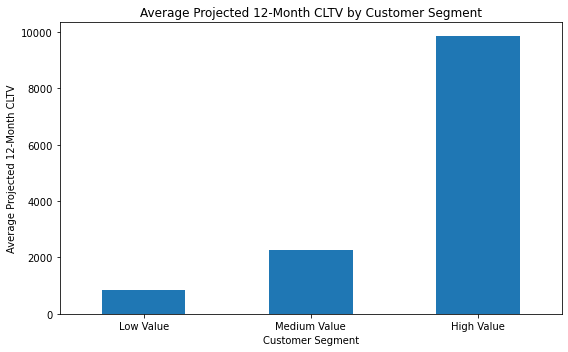

In [229]:
segment_summary["AverageCLTV"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Projected 12-Month CLTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Projected 12-Month CLTV")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [230]:
single_purchase_customers = customer_summary[
    customer_summary["NumberOfOrders"] == 1
]

print("Single-purchase customers:", len(single_purchase_customers))

print(
    "Percentage of customers:",
    round(
        len(single_purchase_customers)
        / len(customer_summary) * 100,
        2
    ),
    "%"
)

Single-purchase customers: 1623
Percentage of customers: 27.61 %


In [232]:
import numpy as np
customer_summary["CustomerType"] = np.where(
    customer_summary["NumberOfOrders"] == 1,
    "Single Purchase",
    "Repeat Customer"
)

In [233]:

customer_summary["CustomerType"].value_counts()

Repeat Customer    4255
Single Purchase    1623
Name: CustomerType, dtype: int64

In [234]:
customer_type_summary = (
    customer_summary
    .groupby("CustomerType")
    .agg(
        NumberOfCustomers=("Projected12MonthCLTV", "count"),
        AverageCLTV=("Projected12MonthCLTV", "mean"),
        AverageRevenue=("TotalRevenue", "mean"),
        AverageOrders=("NumberOfOrders", "mean")
    )
    .round(2)
)

customer_type_summary

,NumberOfCustomers,AverageCLTV,AverageRevenue,AverageOrders
CustomerType,,,,
Repeat Customer,4255,4384.14,3951.71,8.31
Single Purchase,1623,4142.50,345.21,1.00


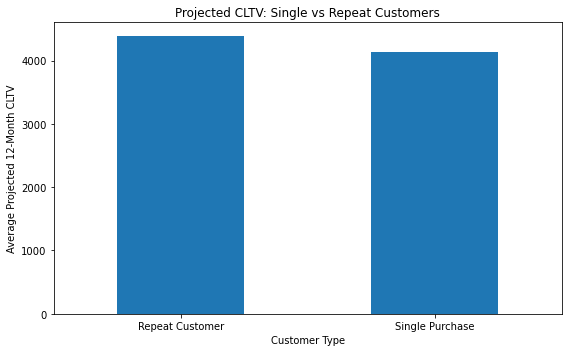

In [235]:
customer_type_summary["AverageCLTV"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Projected CLTV: Single vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Average Projected 12-Month CLTV")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [236]:
top_10_cltv = (
    customer_summary
    .sort_values(
        "Projected12MonthCLTV",
        ascending=False
    )
    .head(10)
)

top_10_cltv[
    [
        "TotalRevenue",
        "NumberOfOrders",
        "AverageOrderValue",
        "Projected12MonthCLTV",
        "CLTVSegment"
    ]
]

,TotalRevenue,NumberOfOrders,AverageOrderValue,Projected12MonthCLTV,CLTVSegment
Customer ID,,,,,
15098.0,39916.50,3,13305.500000,478998.000000,High Value
16446.0,168472.50,2,84236.250000,301664.876471,High Value
18102.0,580987.04,145,4006.807172,287564.967441,High Value
14646.0,528602.52,151,3500.678940,262704.664633,High Value
14096.0,65164.79,17,3833.222941,245395.819497,High Value
17450.0,244784.25,51,4799.691176,208426.085874,High Value
15749.0,44534.30,3,14844.766667,167706.073237,High Value
15760.0,13916.34,2,6958.170000,166996.080000,High Value
14156.0,313437.62,156,2009.215513,157269.909112,High Value


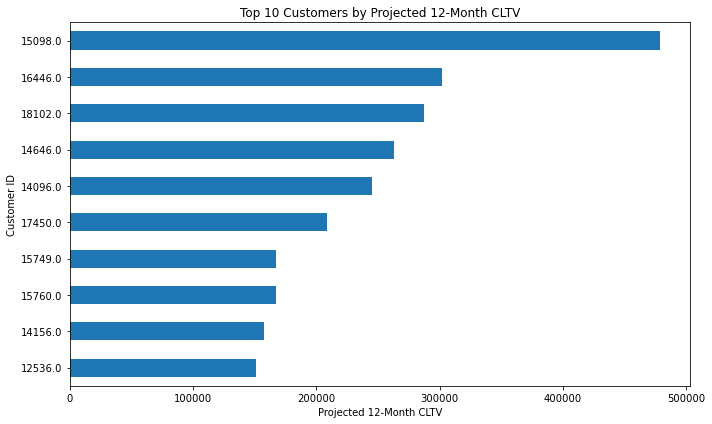

In [237]:
top_10_cltv["Projected12MonthCLTV"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Projected 12-Month CLTV")
plt.xlabel("Projected 12-Month CLTV")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

In [238]:
print("FINAL PROJECT SUMMARY")
print("----------------------------")

print(
    "Total Customers:",
    len(customer_summary)
)

print(
    "Total Revenue:",
    round(customer_summary["TotalRevenue"].sum(), 2)
)

print(
    "Average Order Value:",
    round(customer_summary["AverageOrderValue"].mean(), 2)
)

print(
    "Average Historical CLTV:",
    round(customer_summary["HistoricalCLTV"].mean(), 2)
)

print(
    "Average Projected 12-Month CLTV:",
    round(customer_summary["Projected12MonthCLTV"].mean(), 2)
)

print(
    "Single-Purchase Customers:",
    (customer_summary["NumberOfOrders"] == 1).sum()
)

print(
    "Repeat Customers:",
    (customer_summary["NumberOfOrders"] > 1).sum()
)

FINAL PROJECT SUMMARY
----------------------------
Total Customers: 5878
Total Revenue: 17374804.27
Average Order Value: 385.18
Average Historical CLTV: 2955.9
Average Projected 12-Month CLTV: 4317.42
Single-Purchase Customers: 1623
Repeat Customers: 4255


In [239]:
customer_summary.to_csv(
    "../output/customer_summary_final.csv"
)

segment_summary.to_csv(
    "../output/cltv_segment_summary.csv"
)

customer_type_summary.to_csv(
    "../output/customer_type_summary.csv"
)


In [240]:
print(
    customer_summary[
        [
            "TotalRevenue",
            "AverageOrderValue",
            "HistoricalCLTV",
            "MonthlyCustomerValue",
            "Projected12MonthCLTV"
        ]
    ].isnull().sum()
)

TotalRevenue            0
AverageOrderValue       0
HistoricalCLTV          0
MonthlyCustomerValue    0
Projected12MonthCLTV    0
dtype: int64
